# Bootstrap neural-network workflow with both x and log(x) inputs

This notebook trains neural networks on Gaussian bootstrap replicas of a selected PDF flavor. The key update is that the network input now contains both the raw x information and the logarithmic x information. This follows Professor Prokudin's suggestion and helps the model learn both the large-x behavior and the small-x behavior.


In [1]:
import zipfile
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt

## Device selection

This cell checks whether the notebook is running on GPU or CPU. Training many bootstrap networks is faster on GPU, but the code also works on CPU.


In [2]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)
print("CUDA available:", torch.cuda.is_available())

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))
else:
    print("You are using CPU. Training will be slow.")

Using device: cpu
CUDA available: False
You are using CPU. Training will be slow.


## Load the PDF replica dataset

This cell opens the ZIP file, reads the NumPy dictionary, and lists the available Q² values and PDF flavors. The loaded object contains many PDF replicas for each flavor and scale.


In [6]:
zip_path = '/content/drive/MyDrive/Colab Notebooks/Summer NN/trey24_no_sidis_lo.zip'

with zipfile.ZipFile(zip_path, 'r') as z:
    print("Files inside zip:")
    print(z.namelist())

    # Change this only if z.namelist() shows a different internal path
    with z.open('trey24_no_sidis_lo.npy') as f:
        treypdf = np.load(f, allow_pickle=True).item()

print("Loaded treypdf successfully.")
print("Available Q2 values:", list(treypdf.keys()))
print("Available flavors:", list(treypdf[list(treypdf.keys())[0]].keys()))

Files inside zip:
['trey24_no_sidis_lo.npy']
Loaded treypdf successfully.
Available Q2 values: [1.6129, 10, 100, 500, 1000]
Available flavors: ['uv', 'dv', 'ub', 'db', 's', 'sb', 'c', 'cb', 'b', 'bb', 'g']


In [5]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


## Inspect the dataset structure

This cell prints the shape of each flavor array for each Q² value. This confirms how many replicas and x-grid points are available before choosing a specific slice.


In [7]:
for Q2 in treypdf.keys():
    print("\nQ2 =", Q2)
    for flavor in treypdf[Q2].keys():
        arr = treypdf[Q2][flavor]
        print(flavor, arr.shape)


Q2 = 1.6129
uv (1196, 200)
dv (1196, 200)
ub (1196, 200)
db (1196, 200)
s (1196, 200)
sb (1196, 200)
c (1196, 200)
cb (1196, 200)
b (1196, 200)
bb (1196, 200)
g (1196, 200)

Q2 = 10
uv (1196, 200)
dv (1196, 200)
ub (1196, 200)
db (1196, 200)
s (1196, 200)
sb (1196, 200)
c (1196, 200)
cb (1196, 200)
b (1196, 200)
bb (1196, 200)
g (1196, 200)

Q2 = 100
uv (1196, 200)
dv (1196, 200)
ub (1196, 200)
db (1196, 200)
s (1196, 200)
sb (1196, 200)
c (1196, 200)
cb (1196, 200)
b (1196, 200)
bb (1196, 200)
g (1196, 200)

Q2 = 500
uv (1196, 200)
dv (1196, 200)
ub (1196, 200)
db (1196, 200)
s (1196, 200)
sb (1196, 200)
c (1196, 200)
cb (1196, 200)
b (1196, 200)
bb (1196, 200)
g (1196, 200)

Q2 = 1000
uv (1196, 200)
dv (1196, 200)
ub (1196, 200)
db (1196, 200)
s (1196, 200)
sb (1196, 200)
c (1196, 200)
cb (1196, 200)
b (1196, 200)
bb (1196, 200)
g (1196, 200)


## Choose one Q² value and one flavor

This cell selects a single Q² value and one PDF flavor, such as uv. The bootstrap procedure below is applied to this selected slice of the dataset.


In [8]:
Q2_value = 500
flavor = "uv"

data = treypdf[Q2_value][flavor]

print("Selected Q2:", Q2_value)
print("Selected flavor:", flavor)
print("Data shape:", data.shape)

Selected Q2: 500
Selected flavor: uv
Data shape: (1196, 200)


## Compute the original replica mean and standard deviation

This cell computes the central value and uncertainty of the original PDF replicas. The mean represents the central prediction, while the standard deviation represents the spread across replicas.


In [9]:
mean = data.mean(axis=0)
std = data.std(axis=0, ddof=1)

# Protect against zero or extremely tiny standard deviations
std_safe = np.maximum(std, 1e-8)

print("Mean shape:", mean.shape)
print("Std shape:", std.shape)
print("Mean max:", np.max(mean))
print("Std min:", np.min(std_safe))
print("Std max:", np.max(std_safe))

Mean shape: (200,)
Std shape: (200,)
Mean max: 0.5931037997536043
Std min: 2.6574248704030386e-08
Std max: 0.0020684646487822557


## Generate Gaussian bootstrap replicas

This cell creates new synthetic replicas by sampling from a Gaussian distribution at each x point. The Gaussian mean and standard deviation are taken from the original replica ensemble.


In [10]:
n_new_replicas = 100

gaussian_replicas = np.random.normal(
    loc=mean,
    scale=std_safe,
    size=(n_new_replicas, len(mean))
)

print("Gaussian replicas shape:", gaussian_replicas.shape)

Gaussian replicas shape: (100, 200)


## Build the neural-network inputs: x and log(x)

This is the main update. Each x point is represented by two features: normalized x and normalized log10(x). Raw x helps with the large-x region, while log10(x) expands the small-x region and makes that structure easier for the network to learn.


In [11]:
# Build the input grid for the neural network.
# Professor Prokudin suggested using both x and log(x) as inputs.
# This gives the network two views of the same physics variable:
#   - x helps the model learn the large-x / endpoint region.
#   - log(x) spreads out the small-x region, where PDFs can vary rapidly.

# x grid used for this fixed-Q2 slice
x_grid = np.geomspace(1e-4, 1.0, len(mean))

# Raw x feature, normalized to [-1, 1]
x_raw = x_grid
x_raw_norm = 2 * (x_raw - x_raw.min()) / (x_raw.max() - x_raw.min()) - 1

# Logarithmic x feature, also normalized to [-1, 1]
# We use log10 because the x grid is logarithmically spaced over powers of 10.
x_log = np.log10(x_grid)
x_log_norm = 2 * (x_log - x_log.min()) / (x_log.max() - x_log.min()) - 1

# Combine both features.
# Each training point is now represented as: [normalized x, normalized log10(x)]
X_features = np.column_stack([x_raw_norm, x_log_norm])

# Convert to a PyTorch tensor and move it to the selected device.
X = torch.tensor(X_features, dtype=torch.float32).to(device)

print("x_grid shape:", x_grid.shape)
print("X_features shape:", X_features.shape)
print("X tensor shape:", X.shape)
print("First input row [x_norm, logx_norm]:", X_features[0])
print("Last input row [x_norm, logx_norm]:", X_features[-1])
print("Device:", X.device)


x_grid shape: (200,)
X_features shape: (200, 2)
X tensor shape: torch.Size([200, 2])
First input row [x_norm, logx_norm]: [-1. -1.]
Last input row [x_norm, logx_norm]: [1. 1.]
Device: cpu


## Scale the target values

This cell rescales the PDF values so that the neural network trains on targets closer to order one. Scaling helps optimization and is reversed later when predictions are plotted.


In [12]:
# Scale y so the NN trains more easily.
# The target values can have a much larger or smaller numerical scale than the inputs.
# Dividing by y_scale keeps the training targets closer to order 1.
y_scale = np.max(np.abs(mean))

# Avoid division by zero in pathological cases.
if y_scale == 0:
    y_scale = 1.0

# Scale the uncertainty by the same factor as the target values.
std_scaled = std_safe / y_scale

# This tensor is not used in the simple MSE loss below, but it is useful if
# you later switch to a weighted loss such as ((prediction - target)/std)^2.
std_tensor = torch.tensor(std_scaled.reshape(-1, 1), dtype=torch.float32).to(device)

# Prevent any future weighted loss from exploding because of tiny uncertainties.
std_tensor = torch.clamp(std_tensor, min=1e-6)

print("y_scale:", y_scale)
print("std_tensor min:", std_tensor.min().item())
print("std_tensor max:", std_tensor.max().item())


y_scale: 0.5931037997536043
std_tensor min: 9.999999974752427e-07
std_tensor max: 0.0034875255078077316


## Define the bootstrap neural network

This model maps the two input features, x and log10(x), to one PDF value. A separate model is trained for each bootstrap replica.


In [13]:
class BootstrapPDFNet(nn.Module):
    """
    Neural network used to fit one bootstrap replica of a PDF flavor
    at one fixed Q2 value.

    Input features:
        1. normalized x
        2. normalized log10(x)

    Output:
        the scaled PDF value for the selected flavor.
    """

    def __init__(self, input_dim=2, hidden_dim=128):
        super().__init__()

        self.net = nn.Sequential(
            nn.Linear(input_dim, hidden_dim),
            nn.SiLU(),
            nn.Linear(hidden_dim, hidden_dim),
            nn.SiLU(),
            nn.Linear(hidden_dim, 1)
        )

    def forward(self, x):
        return self.net(x)

# Backward-compatible alias in case later cells still call SimpleNN.
SimpleNN = BootstrapPDFNet


## Sanity check: train one network on one replica

Before training all bootstrap replicas, this cell trains a single network on the first generated replica. This verifies that the architecture and input representation work correctly.


In [14]:
# Train one test model on one Gaussian bootstrap replica.
# This is a sanity check before training all replicas.
test_model = BootstrapPDFNet(input_dim=X.shape[1]).to(device)
optimizer = optim.Adam(test_model.parameters(), lr=1e-3)

# Select the first generated Gaussian replica.
r = 0

# Scale the target and move it to the same device as the model.
y_train = gaussian_replicas[r] / y_scale
y_train = torch.tensor(y_train.reshape(-1, 1), dtype=torch.float32).to(device)

for epoch in range(5000):
    optimizer.zero_grad()

    # The model now receives two input columns: x and log10(x).
    y_pred = test_model(X)

    # Simple mean-squared error on the scaled target.
    loss = torch.mean((y_pred - y_train) ** 2)

    loss.backward()
    optimizer.step()

    if epoch % 1000 == 0:
        print("Epoch:", epoch, "Loss:", loss.item())

print("Final loss:", loss.item())


Epoch: 0 Loss: 0.16335521638393402
Epoch: 1000 Loss: 0.00039482067222706974
Epoch: 2000 Loss: 0.0002047029120149091
Epoch: 3000 Loss: 0.00021629281400237232
Epoch: 4000 Loss: 0.00014442451356444508
Final loss: 0.00010243817087030038


## Plot the one-replica test fit

This cell compares the first Gaussian replica with the prediction of the test neural network. The plot should show whether the model can fit one representative replica.


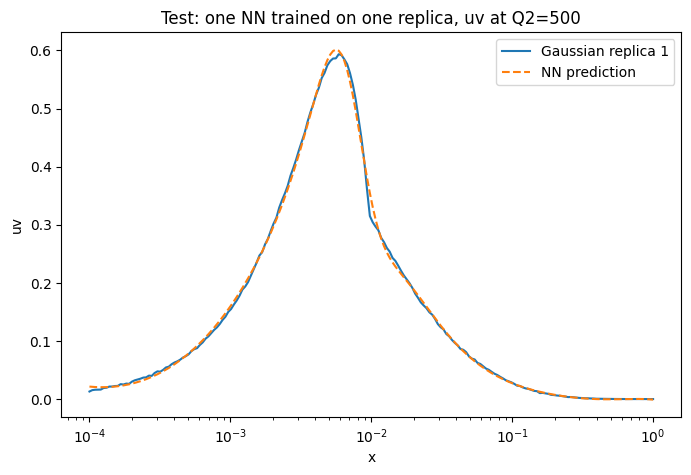

In [15]:
with torch.no_grad():
    test_pred_scaled = test_model(X).cpu().numpy().flatten()
    test_pred = test_pred_scaled * y_scale

plt.figure(figsize=(8, 5))

plt.plot(x_grid, gaussian_replicas[0], label="Gaussian replica 1")
plt.plot(x_grid, test_pred, "--", label="NN prediction")

plt.xscale("log")
plt.xlabel("x")
plt.ylabel(flavor)
plt.title(f"Test: one NN trained on one replica, {flavor} at Q2={Q2_value}")
plt.legend()
plt.show()

## Train one neural network per bootstrap replica

This is the core bootstrap training loop. Each generated replica gets its own neural network. The ensemble of trained networks is then used to estimate the neural-network mean and uncertainty.


In [16]:
models = []
losses = []

max_epochs = 5000
target_loss = 1e-5

for r in range(n_new_replicas):
    print("Training replica", r + 1, "of", n_new_replicas)

    # Create a new independent neural network for each bootstrap replica.
    model = BootstrapPDFNet(input_dim=X.shape[1]).to(device)
    optimizer = optim.Adam(model.parameters(), lr=1e-3)

    # Scale the selected replica and move it to the same device as the model.
    y_train = gaussian_replicas[r] / y_scale
    y_train = torch.tensor(y_train.reshape(-1, 1), dtype=torch.float32).to(device)

    for epoch in range(max_epochs):
        optimizer.zero_grad()

        # Input contains both normalized x and normalized log10(x).
        y_pred = model(X)
        loss = torch.mean((y_pred - y_train) ** 2)

        loss.backward()
        optimizer.step()

        # Early stopping: stop once the fit is already sufficiently accurate.
        if loss.item() < target_loss:
            break

    models.append(model)
    losses.append(loss.item())

    print("  final loss:", loss.item(), "epochs:", epoch + 1)

print("Finished training.")
print("Average final loss:", np.mean(losses))
print("Minimum final loss:", np.min(losses))
print("Maximum final loss:", np.max(losses))


Training replica 1 of 100
  final loss: 0.00012066727504134178 epochs: 5000
Training replica 2 of 100
  final loss: 8.09666671557352e-05 epochs: 5000
Training replica 3 of 100
  final loss: 0.00010841256153071299 epochs: 5000
Training replica 4 of 100
  final loss: 0.00012025600881315768 epochs: 5000
Training replica 5 of 100
  final loss: 0.00013603304978460073 epochs: 5000
Training replica 6 of 100
  final loss: 0.000128136423882097 epochs: 5000
Training replica 7 of 100
  final loss: 0.0001806794898584485 epochs: 5000
Training replica 8 of 100
  final loss: 0.00030798997613601387 epochs: 5000
Training replica 9 of 100
  final loss: 0.000123142046504654 epochs: 5000
Training replica 10 of 100
  final loss: 0.00012877339031547308 epochs: 5000
Training replica 11 of 100
  final loss: 0.00012247997801750898 epochs: 5000
Training replica 12 of 100
  final loss: 0.00019488472025841475 epochs: 5000
Training replica 13 of 100
  final loss: 5.15773608640302e-05 epochs: 5000
Training replica 

## Collect predictions from all trained networks

This cell evaluates every trained network on the same x-grid and stores the predictions. These predictions form the neural-network ensemble.


In [17]:
predictions = []

with torch.no_grad():
    for model in models:
        pred_scaled = model(X).cpu().numpy().flatten()
        pred = pred_scaled * y_scale
        predictions.append(pred)

predictions = np.array(predictions)

print("Predictions shape:", predictions.shape)

Predictions shape: (100, 200)


## Compute the neural-network mean and uncertainty

This cell computes the mean and standard deviation across the neural-network predictions. These are compared with the original PDF mean and standard deviation.


In [18]:
nn_mean = predictions.mean(axis=0)
nn_std = predictions.std(axis=0, ddof=1)

print("NN mean shape:", nn_mean.shape)
print("NN std shape:", nn_std.shape)

NN mean shape: (200,)
NN std shape: (200,)


## Compare original PDF uncertainty with neural-network uncertainty

This plot compares the original replica band with the neural-network bootstrap band. The goal is not only to fit the mean, but also to reproduce the uncertainty.


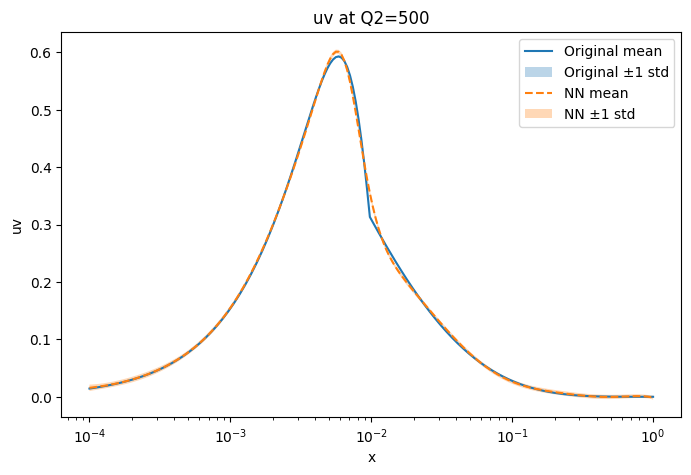

In [19]:
plt.figure(figsize=(8, 5))

plt.plot(x_grid, mean, label="Original mean")
plt.fill_between(
    x_grid,
    mean - std,
    mean + std,
    alpha=0.3,
    label="Original ±1 std"
)

plt.plot(x_grid, nn_mean, "--", label="NN mean")
plt.fill_between(
    x_grid,
    nn_mean - nn_std,
    nn_mean + nn_std,
    alpha=0.3,
    label="NN ±1 std"
)

plt.xscale("log")
plt.xlabel("x")
plt.ylabel(flavor)
plt.title(f"{flavor} at Q2={Q2_value}")
plt.legend()
plt.show()

## Quantify the agreement

This cell computes relative errors between the original PDF statistics and the neural-network statistics. Low mean error and low standard-deviation error indicate better reproduction of the original ensemble.


In [20]:
mean_error = np.mean(np.abs(nn_mean - mean) / (np.abs(mean) + 1e-12))
std_error = np.mean(np.abs(nn_std - std) / (np.abs(std) + 1e-12))

print("Mean relative error:", mean_error)
print("Std relative error:", std_error)

Mean relative error: 181.21420616119593
Std relative error: 2111.7930979323196


## Inspect final training losses

This cell plots the final loss for each replica-specific network. Large outliers may indicate replicas that were harder to fit or training instability.


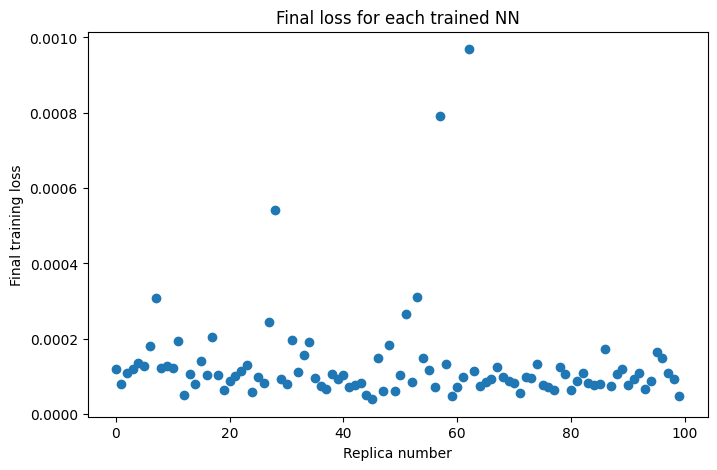

Average loss: 0.0001298839343144209


In [21]:
plt.figure(figsize=(8, 5))

plt.plot(losses, marker="o", linestyle="none")
plt.xlabel("Replica number")
plt.ylabel("Final training loss")
plt.title("Final loss for each trained NN")
plt.show()

print("Average loss:", np.mean(losses))

## Save the bootstrap results

This cell saves the x grid, input features, original statistics, generated replicas, neural-network predictions, and final losses. The filename records that the model used both x and log(x) inputs.


In [22]:
output_file = f"bootstrap_nn_predictions_{flavor}_Q2_{Q2_value}_x_logx_inputs.npz"

np.savez(
    output_file,
    x_grid=x_grid,
    x_raw_norm=x_raw_norm,
    x_log_norm=x_log_norm,
    X_features=X_features,
    mean=mean,
    std=std,
    gaussian_replicas=gaussian_replicas,
    predictions=predictions,
    nn_mean=nn_mean,
    nn_std=nn_std,
    losses=np.array(losses)
)

print("Saved:", output_file)


Saved: bootstrap_nn_predictions_uv_Q2_500_x_logx_inputs.npz
